<a href="https://colab.research.google.com/github/danielruizm16/ComputationalMethods_2026_I/blob/main/Rep_Numérica_Errores/Rep_Numérica_Errores.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Representación Numérica, Errores y Estabilidad.

In [1]:
from math import factorial
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## mybin
Escriba una función llamada `mybin` que tome un número entero real de 16 bits y realice su conversión a código binario, compare su resultado con `bin(4321)`.


In [2]:
def mybin(num):
    """
    Convierte un número entero de 16 bits a su representación binaria.

    Argumentos:
        num (int): Número entero a convertir (se asume que es de 16 bits)

    Retorna:
        str: Cadena que representa el número en binario, con el prefijo '0b'
    """
    # Verifica si el número está dentro del rango de 16 bits
    if num < -2**16 or num > 2**16 - 1:
        raise ValueError("El número debe estar en el rango de 16 bits (-32768 a 32767)")

    # Maneja números negativos
    signo = '-' if num < 0 else ''
    num = abs(num)

    # Convierte a binario manualmente
    binario = []
    while num > 0:
        binario.append(str(num % 2))
        num = num // 2
    # Invierte el orden de los bits
    binario.reverse()
    resultado = signo + '0b' + ''.join(binario)

    return resultado

# Prueba la función con 4321 y compara con bin(4321)
numero = 4321
mi_resultado = mybin(numero)
resultado_python = bin(numero)

print(f"mybin({numero}): {mi_resultado}")
print(f"bin({numero}):   {resultado_python}")

mybin(4321): 0b1000011100001
bin(4321):   0b1000011100001


## Serie Binomial
La serie de Taylor para la función $(1+x)^\alpha$, conocida como serie binomial, centrada en $a=0$ está dada por:
$$(1+x)^\alpha = \sum_{n=0}^{\infty} \binom{\alpha}{n} x^n = 1 + \alpha x + \frac{\alpha(\alpha-1)}{2!} x^2 + \frac{\alpha(\alpha-1)(\alpha-2)}{3!} x^3 + \cdots$$
donde $\binom{\alpha}{n}$ es el coeficiente binomial generalizado.

Considere el caso donde $\alpha = 1/2$, lo que nos da la serie de Taylor para $\sqrt{1+x}$:
$$\sqrt{1+x} = \sum_{n=0}^{\infty} \binom{1/2}{n} x^n = 1 + \frac{1}{2} x - \frac{1}{8} x^2 + \frac{1}{16} x^3 - \frac{5}{128} x^4 + \cdots$$

- Encuentre la aproximación para $x = 0.5$ cambiando el número de términos incluidos en la suma. ¿Qué puede concluir sobre la convergencia de la serie para este valor de $x$?
- Encuentre el error relativo y porcentual para cada aproximación, utilizando el valor real de $\sqrt{1+0.5} = \sqrt{1.5} \approx 1.224744871$. 
- Grafique los valores asociados a la serie después de cada iteración. Muestre cómo la serie se aproxima al valor real a medida que se incluyen más términos.
- Usando el criterio de tolerancia, evalúe de 6 a 7 valores diferentes, y encuentre cuántos términos se necesitan para alcanzar esa precisión. Cree una gráfica de la evolución del sistema.

In [3]:
def coeficiente_binomial(alpha, n):
    """Calcula el coeficiente binomial generalizado (alpha elige n)"""
    if n == 0:
        return 1
    resultado = 1
    for i in range(n):
        resultado *= (alpha - i)
    return resultado / factorial(n)

def aproximacion_taylor_binomial(x, alpha, n_terminos):
    """Calcula la aproximación de la serie de Taylor para (1+x)^alpha"""
    aproximacion = 0
    for n in range(n_terminos):
        aproximacion += coeficiente_binomial(alpha, n) * (x ** n)
    return aproximacion

In [4]:
# Parámetros
x = 0.5
alpha = 0.5
max_terminos = 20
valor_real = np.sqrt(1+x)

# Calcula aproximaciones para diferentes números de términos
resultados = []
aproximaciones = []

for n_terminos in range(1, max_terminos + 1):
    aprox = aproximacion_taylor_binomial(x, alpha, n_terminos)
    aproximaciones.append(aprox)
    
    error_absoluto = abs(valor_real - aprox)
    error_relativo = error_absoluto / valor_real
    error_porcentual = error_relativo * 100
    
    resultados.append({
        'Términos': n_terminos,
        'Aproximación': aprox,
        'Error_Absoluto': error_absoluto,
        'Error_Relativo': error_relativo,
        'Error_Porcentual': error_porcentual
    })

# Crear DataFrame
df = pd.DataFrame(resultados)
df

,Términos,Aproximación,Error_Absoluto,Error_Relativo,Error_Porcentual
0,1,1.000000,2.247449e-01,1.835034e-01,1.835034e+01
1,2,1.250000,2.525513e-02,2.062073e-02,2.062073e+00
2,3,1.218750,5.994871e-03,4.894792e-03,4.894792e-01
3,4,1.226562,1.817629e-03,1.484088e-03,1.484088e-01
4,5,1.224121,6.237776e-04,5.093123e-04,5.093123e-02
5,6,1.224976,2.307145e-04,1.883776e-04,1.883776e-02
6,7,1.224655,8.972002e-05,7.325609e-05,7.325609e-03
7,8,1.224781,3.616499e-05,2.952859e-05,2.952859e-03
8,9,1.224730,1.497580e-05,1.222769e-05,1.222769e-03
9,10,1.224751,6.332861e-06,5.170759e-06,5.170759e-04


In [5]:
# Crear DataFrame
df = pd.DataFrame(resultados)
df

,Términos,Aproximación,Error_Absoluto,Error_Relativo,Error_Porcentual
0,1,1.000000,2.247449e-01,1.835034e-01,1.835034e+01
1,2,1.250000,2.525513e-02,2.062073e-02,2.062073e+00
2,3,1.218750,5.994871e-03,4.894792e-03,4.894792e-01
3,4,1.226562,1.817629e-03,1.484088e-03,1.484088e-01
4,5,1.224121,6.237776e-04,5.093123e-04,5.093123e-02
5,6,1.224976,2.307145e-04,1.883776e-04,1.883776e-02
6,7,1.224655,8.972002e-05,7.325609e-05,7.325609e-03
7,8,1.224781,3.616499e-05,2.952859e-05,2.952859e-03
8,9,1.224730,1.497580e-05,1.222769e-05,1.222769e-03
9,10,1.224751,6.332861e-06,5.170759e-06,5.170759e-04


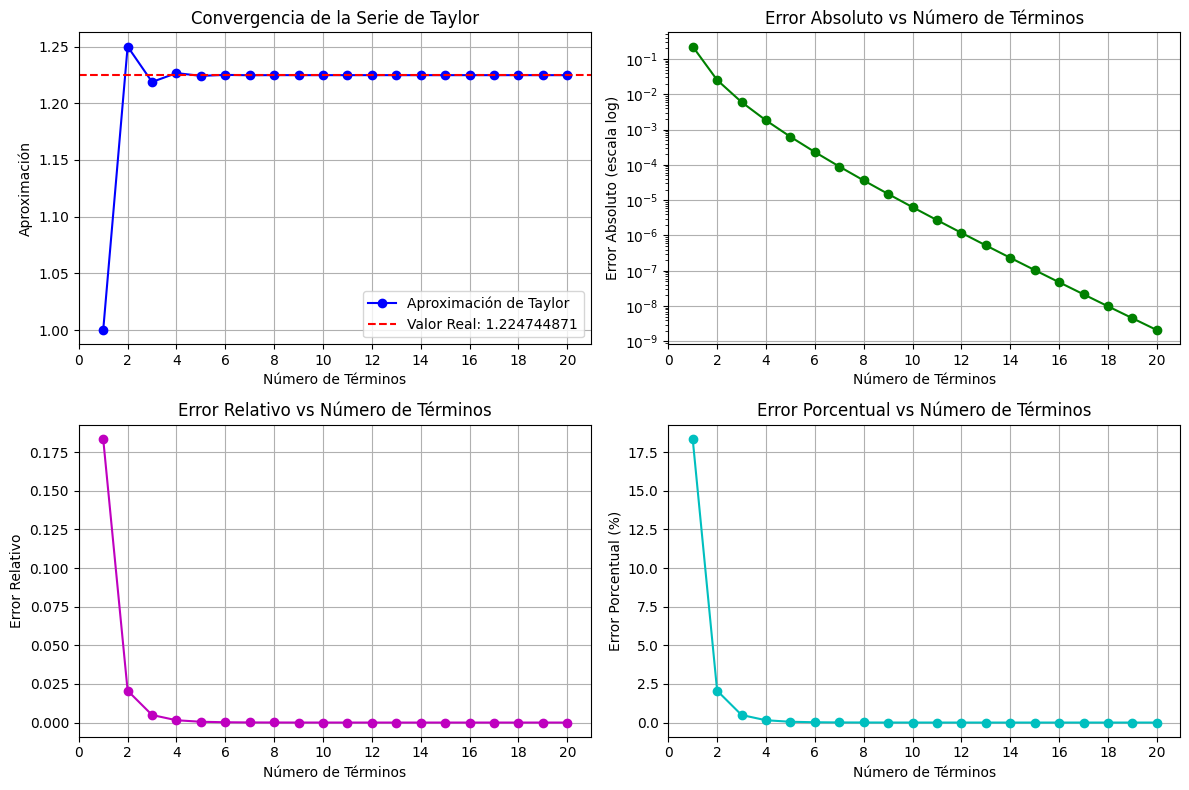

In [6]:
# Graficar convergencia
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(df['Términos'], df['Aproximación'], 'bo-', label='Aproximación de Taylor')
plt.axhline(y=valor_real, color='r', linestyle='--', label=f'Valor Real: {valor_real:.9f}')
plt.xlabel('Número de Términos')
plt.ylabel('Aproximación')
plt.title('Convergencia de la Serie de Taylor')
plt.legend()
plt.grid()
plt.xticks(range(0, max_terminos + 1, 2))

plt.subplot(2, 2, 2)
plt.semilogy(df['Términos'], df['Error_Absoluto'], 'go-')
plt.xlabel('Número de Términos')
plt.ylabel('Error Absoluto (escala log)')
plt.title('Error Absoluto vs Número de Términos')
plt.grid()
plt.xticks(range(0, max_terminos + 1, 2))

plt.subplot(2, 2, 3)
plt.plot(df['Términos'], df['Error_Relativo'], 'mo-')
plt.xlabel('Número de Términos')
plt.ylabel('Error Relativo')
plt.title('Error Relativo vs Número de Términos')
plt.grid()
plt.xticks(range(0, max_terminos + 1, 2))

plt.subplot(2, 2, 4)
plt.plot(df['Términos'], df['Error_Porcentual'], 'co-')
plt.xlabel('Número de Términos')
plt.ylabel('Error Porcentual (%)')
plt.title('Error Porcentual vs Número de Términos')
plt.grid()
plt.xticks(range(0, max_terminos + 1, 2))

plt.tight_layout()
plt.show()

In [7]:
# Análisis de tolerancia
def terminos_necesarios_para_tolerancia(x, alpha, tolerancia):
    """Encuentra el número de términos necesarios para alcanzar una tolerancia dada"""
    n_terminos = 1
    while True:
        aprox = aproximacion_taylor_binomial(x, alpha, n_terminos)
        error = abs(valor_real - aprox)
        if error <= tolerancia:
            return n_terminos, aprox, error
        n_terminos += 1
        if n_terminos > 100:  # Límite de seguridad
            return n_terminos, aprox, error

# Prueba diferentes valores de tolerancia
tolerancias = [1e-2, 1e-3, 1e-4, 1e-5, 1e-6, 1e-7, 1e-8]
resultados_tolerancia = []

for tol in tolerancias:
    terminos, aprox_final, error_final = terminos_necesarios_para_tolerancia(x, alpha, tol)
    resultados_tolerancia.append({
        'Tolerancia': tol,
        'Términos_Necesarios': terminos,
        'Aproximación_Final': aprox_final,
        'Error_Final': error_final
    })

# Crear DataFrame para el análisis de tolerancia
tolerancia_df = pd.DataFrame(resultados_tolerancia)
tolerancia_df

,Tolerancia,Términos_Necesarios,Aproximación_Final,Error_Final
0,1.000000e-02,3,1.218750,5.994871e-03
1,1.000000e-03,5,1.224121,6.237776e-04
2,1.000000e-04,7,1.224655,8.972002e-05
3,1.000000e-05,10,1.224751,6.332861e-06
4,1.000000e-06,13,1.224744,5.235943e-07
5,1.000000e-07,16,1.224745,4.734141e-08
6,1.000000e-08,18,1.224745,9.859308e-09


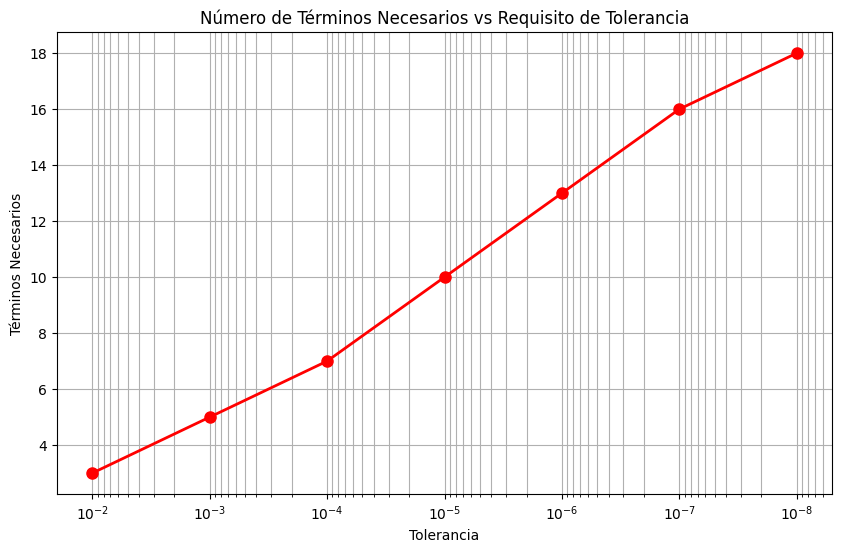

In [8]:
# Graficar análisis de tolerancia
plt.figure(figsize=(10, 6))
plt.semilogx(tolerancia_df['Tolerancia'], tolerancia_df['Términos_Necesarios'], 'ro-', linewidth=2, markersize=8)
plt.xlabel('Tolerancia')
plt.ylabel('Términos Necesarios')
plt.title('Número de Términos Necesarios vs Requisito de Tolerancia')
plt.grid(True, which="both", ls="-")
plt.gca().invert_xaxis()  # Tolerancia más pequeña a la derecha
plt.show()